In [2]:
import pandas as pd
import os

In [3]:
os.getcwd()

'C:\\Users\\rrron\\OneDrive\\Desktop\\Primetrade_Assignment\\notebook'

In [4]:
os.listdir()

['.ipynb_checkpoints', 'analysis.ipynb']

In [5]:
trader= pd.read_csv("../data/historical_data.csv") ## .. used because data is parent folder

In [6]:
sentiment= pd.read_csv("../data/fear_greed_index.csv")

In [7]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
trader.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [10]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [11]:
trader.info() ## from here we can see that timestamp IST column is of object data type ,we should convert this into datetime format

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
sentiment.info() ## there are no missing values in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [13]:
trader['Timestamp IST']=pd.to_datetime(trader['Timestamp IST'],dayfirst=True)

In [14]:
trader['Timestamp IST'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 211224 entries, 0 to 211223
Series name: Timestamp IST
Non-Null Count   Dtype         
--------------   -----         
211224 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.6 MB


In [15]:
trader['Date']=trader['Timestamp IST'].dt.date

In [16]:
sentiment['date'].info() ## here also datatype is object, convert to datetime

<class 'pandas.core.series.Series'>
RangeIndex: 2644 entries, 0 to 2643
Series name: date
Non-Null Count  Dtype 
--------------  ----- 
2644 non-null   object
dtypes: object(1)
memory usage: 20.8+ KB


In [17]:
sentiment['date']=pd.to_datetime(sentiment['date'])

In [18]:
sentiment['Date']=sentiment['date'].dt.date

In [19]:
## now checking dates
trader[['Timestamp IST','Date']].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [20]:
sentiment[['date','Date']].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


 Merging both the dataset on the basis of common column date

In [21]:
sentiment.tail()

,timestamp,value,classification,date,Date
2639,1745818200,54,Neutral,2025-04-28,2025-04-28
2640,1745904600,60,Greed,2025-04-29,2025-04-29
2641,1745991000,56,Greed,2025-04-30,2025-04-30
2642,1746077400,53,Neutral,2025-05-01,2025-05-01
2643,1746163800,67,Greed,2025-05-02,2025-05-02


In [22]:
# since we already have Date column in sentiment analysis, hence removing timestamp from merged df
merged= pd.merge( trader, sentiment[['Date','classification','value']],
                 on='Date',how='left')

In [23]:
merged.tail() ## now every trade knows the market sentiment of that day

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,2025-04-25 15:35:00,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25,Greed,60.0
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,2025-04-25 15:35:00,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25,Greed,60.0
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,2025-04-25 15:35:00,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25,Greed,60.0
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,2025-04-25 15:35:00,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25,Greed,60.0
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,2025-04-25 15:35:00,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12,2025-04-25,Greed,60.0


In [24]:
merged['classification'].isnull().sum() ## since we have 6 null values , we will drop them as it is very small number compare to 211224 rows

np.int64(6)

In [25]:
merged[merged['classification'].isnull()][['Timestamp IST','Date']].head(10)

,Timestamp IST,Date
727,2024-10-26 04:44:00,2024-10-26
728,2024-10-26 04:52:00,2024-10-26
729,2024-10-26 04:52:00,2024-10-26
730,2024-10-26 04:52:00,2024-10-26
731,2024-10-26 04:52:00,2024-10-26
732,2024-10-26 04:53:00,2024-10-26


In [26]:
merged = merged.dropna(subset=['classification'])

In [27]:
merged['classification'].isnull().sum()

np.int64(0)

In [28]:
merged.groupby('classification')['Closed PnL'].agg(['count','mean','median','sum']).sort_values('mean',ascending=False)

,count,mean,median,sum
classification,,,,
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Fear,61837,54.290400,0.0,3.357155e+06
Greed,50303,42.743559,0.0,2.150129e+06
Extreme Fear,21400,34.537862,0.0,7.391102e+05
Neutral,37686,34.307718,0.0,1.292921e+06


### Observation
- Extreme Greed shows the highest average profit per trade (67.89).
- Fear periods generated the highest total profit due to larger trading activity.
- Trading activity was highest during Fear periods.
- Median PnL is 0 across all sentiment categories, suggesting many trades generated little or no realized profit.

WIN RATE ANALYSIS

In [29]:
merged['win']=merged['Closed PnL']>0

In [30]:
win_rate = merged.groupby('classification')['win'].mean() * 100
win_rate.sort_values(ascending=False)

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: win, dtype: float64

### Observation

- Extreme Greed exhibited the highest win rate (46.49%).
- Extreme Fear showed the lowest win rate (37.06%).
- Traders were more likely to close trades profitably during highly bullish market conditions.
- As market sentiment became more pessimistic, the probability of profitable trades generally declined.

In [31]:
pd.pivot_table(
    merged,
    values='Closed PnL',
    index='classification',
    columns='Side',
    aggfunc='mean'
)

Side,BUY,SELL
classification,,
Extreme Fear,34.114627,34.980106
Extreme Greed,10.498927,114.584643
Fear,63.927104,45.049641
Greed,25.002302,59.691091
Neutral,29.227429,39.456408


### Observation
- BUY trades were more profitable during Fear periods.
- SELL trades outperformed BUY trades during Greed and Extreme Greed periods.
- The largest average profit was observed in SELL trades during Extreme Greed (114.58).
- This suggests traders may have benefited from taking profits or short positions when market optimism became excessive.

In [32]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
top_traders.head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64

In [33]:
merged.groupby('Account')['Closed PnL'].sum().head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    4.788532e+04
0x271b280974205ca63b716753467d5a371de622ab   -7.043619e+04
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.324648e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686580e+05
Name: Closed PnL, dtype: float64

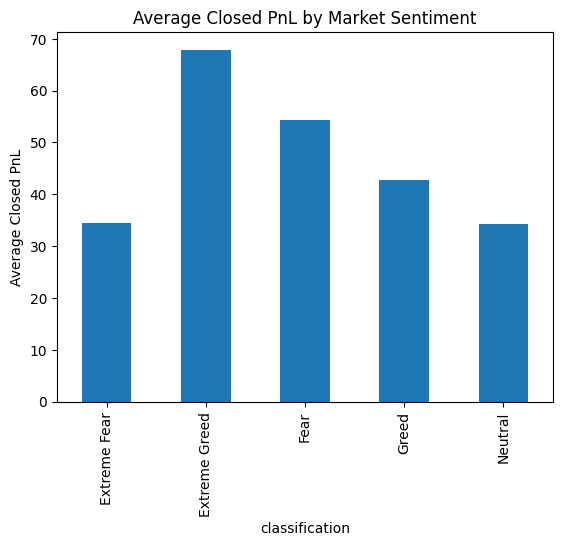

In [34]:
import matplotlib.pyplot as plt
avg_pnl = merged.groupby('classification')['Closed PnL'].mean()
avg_pnl.plot(kind='bar')
plt.title('Average Closed PnL by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

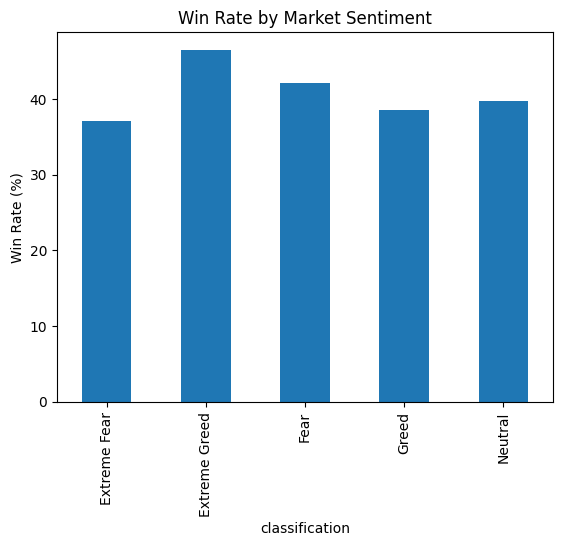

In [35]:
win_rate.plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.show()

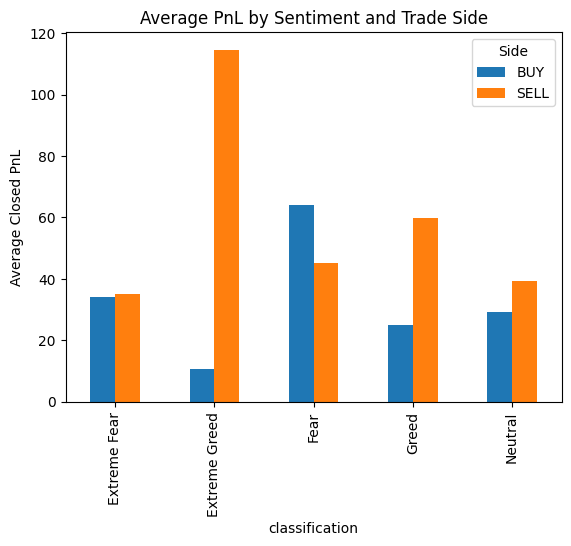

In [36]:
buy_sell = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='classification',
    columns='Side',
    aggfunc='mean'
)

buy_sell.plot(kind='bar')

plt.title('Average PnL by Sentiment and Trade Side')
plt.ylabel('Average Closed PnL')
plt.show()